# 📈 Ejemplo Práctico — Promedios Móviles (SMA y EMA)
### Análisis del precio de una acción tecnológica: TechCorp 2024

**Equipo:** Alejandro Riveros · César Díaz · Carlos Montaña · Santiago Prieto

---

En este notebook vamos a responder una pregunta muy concreta:

> **¿Cómo podemos ver la tendencia real del precio de una acción, ignorando el ruido del día a día?**

Para eso usaremos dos herramientas: **SMA** y **EMA**.

**Lo que haremos paso a paso:**
1. Cargar el precio diario de TechCorp durante 1 año
2. Aplicar SMA para suavizar el ruido
3. Aplicar EMA y comparar con el SMA
4. Detectar señales de compra y venta automáticas
5. Ver cuánto dinero hubiéramos ganado siguiendo esas señales


## ⚙️ Paso 0 — Preparación: cargar las librerías

Antes de empezar, cargamos las herramientas que vamos a usar.  
No hace falta entenderlas todas — son como los ingredientes antes de cocinar. 🧑‍🍳


In [1]:
import pandas as pd        # para manejar tablas de datos
import numpy as np         # para cálculos matemáticos
import matplotlib.pyplot as plt   # para hacer gráficas
import warnings
warnings.filterwarnings('ignore')

# Estilo de las gráficas
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize']  = 13

print("✅ Todo listo para empezar")


✅ Todo listo para empezar


## 📊 Paso 1 — Los datos: precio diario de TechCorp

Trabajamos con el **precio de cierre diario** de una acción tecnológica llamada TechCorp durante todo el año 2024 (252 días hábiles de bolsa).

El precio parte en **$150** y tiene movimientos aleatorios — igual que cualquier acción real.  
Además, simulamos **3 eventos** que ocurren durante el año:

| Evento | Efecto |
|--------|--------|
| Q1 Earnings Miss (resultados peores de lo esperado) | 📉 Caída brusca |
| Lanzamiento de nuevo producto | 📈 Rally (subida rápida) |
| Corrección técnica | 📉 Bajada moderada |

> 💡 Estos eventos crean exactamente el tipo de **ruido y cambios bruscos** que los promedios móviles deben manejar.


In [2]:
# ── Generamos los datos de precio ────────────────────────────────────────────
np.random.seed(2024)   # semilla fija: siempre obtendremos los mismos datos

n    = 252             # días hábiles en un año bursátil
S0   = 150             # precio inicial: $150
mu   = 0.18            # tendencia anual: +18%
sigma = 0.25           # volatilidad anual: 25% (cuánto fluctúa)

# Simulación de precio con tendencia + movimiento aleatorio
dt = 1 / n
W  = np.cumsum(np.random.standard_normal(n)) * np.sqrt(dt)
t  = np.linspace(0, 1, n)
precios = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

# Añadimos los 3 eventos del año
precios[55:75]   -= np.linspace(0, 18, 20)   # caída: Q1 Earnings Miss
precios[75:95]   += np.linspace(0, 12, 20)   # recuperación gradual
precios[140:155] += np.linspace(0, 22, 15)   # rally: lanzamiento producto
precios[195:210] -= np.linspace(0, 14, 15)   # corrección técnica
precios = np.maximum(precios, 80)             # el precio no puede bajar de $80

# Creamos la tabla de datos con fechas reales
fechas = pd.bdate_range(start='2024-01-02', periods=n)   # días hábiles
df = pd.DataFrame({'Precio': precios}, index=fechas)

# Mostramos un resumen
print("📋 Primeros 8 días del año:")
print(df.head(8).round(2))
print()
print(f"📅 Período:        {df.index[0].date()}  →  {df.index[-1].date()}")
print(f"📏 Total de días:  {len(df)} días hábiles")
print(f"💰 Precio inicial: ${df['Precio'].iloc[0]:.2f}")
print(f"💰 Precio final:   ${df['Precio'].iloc[-1]:.2f}")
print(f"📈 Variación:      {((df['Precio'].iloc[-1]/df['Precio'].iloc[0])-1)*100:+.1f}% en el año")


📋 Primeros 8 días del año:
            Precio
2024-01-02  153.99
2024-01-03  155.88
2024-01-04  155.48
2024-01-05  155.20
2024-01-08  157.55
2024-01-09  160.55
2024-01-10  154.16
2024-01-11  151.06

📅 Período:        2024-01-02  →  2024-12-18
📏 Total de días:  252 días hábiles
💰 Precio inicial: $153.99
💰 Precio final:   $180.11
📈 Variación:      +17.0% en el año


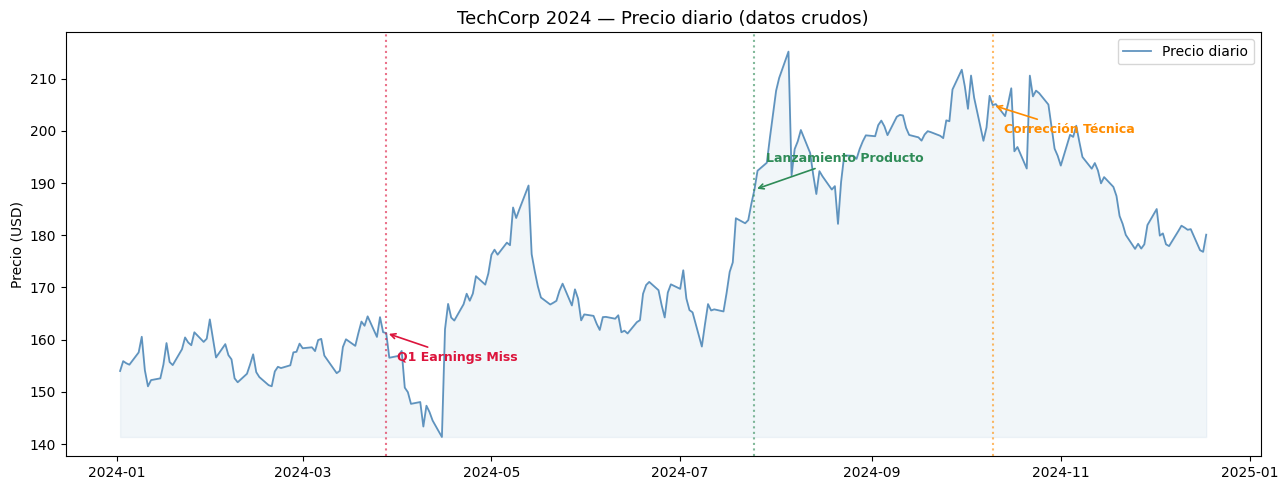

👆 Fíjate en el zigzag constante — ese es el RUIDO que dificulta ver la tendencia real.
   Los promedios móviles nos ayudarán a 'limpiar' esa señal.


In [3]:
# ── Visualizamos los datos crudos ────────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(df.index, df['Precio'], color='steelblue', linewidth=1.3, alpha=0.85, label='Precio diario')
ax.fill_between(df.index, df['Precio'], df['Precio'].min(), alpha=0.07, color='steelblue')

# Marcamos los eventos con flechas
eventos = {
    df.index[62]:  ('Q1 Earnings Miss',    'crimson',    -20),
    df.index[147]: ('Lanzamiento Producto', 'seagreen',   +20),
    df.index[202]: ('Corrección Técnica',   'darkorange', -20),
}
for fecha, (label, color, offset) in eventos.items():
    ax.axvline(x=fecha, color=color, linestyle=':', alpha=0.6, linewidth=1.5)
    ax.annotate(label, xy=(fecha, df.loc[fecha, 'Precio']),
                xytext=(8, offset), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.set_title('TechCorp 2024 — Precio diario (datos crudos)')
ax.set_ylabel('Precio (USD)')
ax.legend()
plt.tight_layout()
plt.show()

print("👆 Fíjate en el zigzag constante — ese es el RUIDO que dificulta ver la tendencia real.")
print("   Los promedios móviles nos ayudarán a 'limpiar' esa señal.")


## 📐 Paso 2 — Simple Moving Average (SMA)

El SMA es el promedio de los últimos **N días**. Simple y directo.

**¿Cómo funciona?**  
Si N = 7, cada punto del SMA es el promedio de los 7 días anteriores.  
Cuando llega un día nuevo, entra en el promedio y el más antiguo sale.  
Por eso se llama "móvil" — la ventana se desplaza.

**Probaremos 3 ventanas:**

| Ventana | ¿Para qué sirve? |
|---------|-----------------|
| SMA(7)  | Ver la tendencia de la última semana — muy reactivo |
| SMA(21) | Tendencia mensual — balance entre detalle y suavidad |
| SMA(50) | Tendencia trimestral — muy suave, ignora variaciones cortas |


In [4]:
# ── Calculamos los 3 SMA con pandas ─────────────────────────────────────────
# .rolling(N) define la ventana  |  .mean() calcula el promedio

df['SMA_7']  = df['Precio'].rolling(window=7).mean()
df['SMA_21'] = df['Precio'].rolling(window=21).mean()
df['SMA_50'] = df['Precio'].rolling(window=50).mean()

# Mostramos los valores alrededor del primer evento (día ~62)
print("📋 Precio vs SMA — semana del Q1 Earnings Miss:")
print(df[['Precio', 'SMA_7', 'SMA_21', 'SMA_50']].iloc[58:68].round(2))
print()
print("⚠️  Nota: el SMA(50) tiene NaN en las primeras 49 filas.")
print("   Necesita al menos 50 datos para dar su primer resultado.")


📋 Precio vs SMA — semana del Q1 Earnings Miss:
            Precio   SMA_7  SMA_21  SMA_50
2024-03-22  164.47  161.33  158.44  157.29
2024-03-25  160.53  161.61  158.72  157.45
2024-03-26  164.31  162.21  159.16  157.63
2024-03-27  161.43  162.58  159.34  157.67
2024-03-28  161.27  162.59  159.51  157.78
2024-03-29  156.53  161.60  159.39  157.81
2024-04-01  156.89  160.77  159.32  157.78
2024-04-02  157.83  159.83  159.28  157.73
2024-04-03  150.81  158.44  158.95  157.56
2024-04-04  149.94  156.38  158.47  157.38

⚠️  Nota: el SMA(50) tiene NaN en las primeras 49 filas.
   Necesita al menos 50 datos para dar su primer resultado.


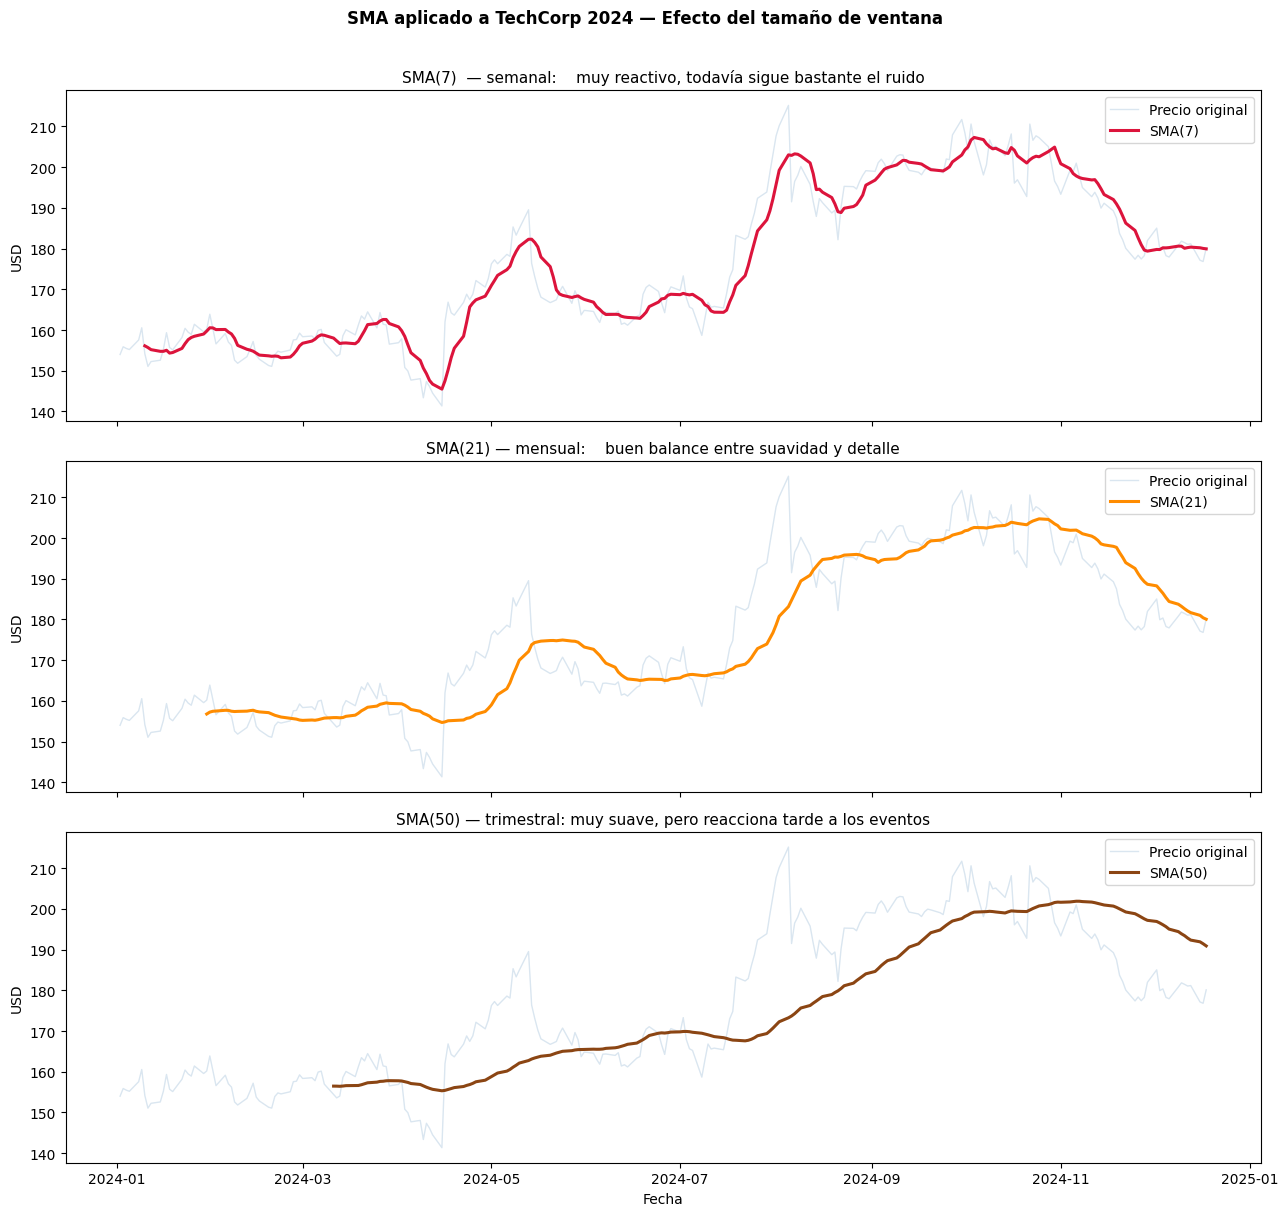

💡 Observación clave:
   SMA(7)  → sigue de cerca el precio, pero todavía hay ruido.
   SMA(21) → más suave y ya se ve bien la tendencia general.
   SMA(50) → muy limpio, pero detecta los eventos con mucho retraso.


In [5]:
# ── Graficamos los 3 SMA ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

configs = [
    ('SMA_7',  'crimson',    'SMA(7)  — semanal:    muy reactivo, todavía sigue bastante el ruido'),
    ('SMA_21', 'darkorange', 'SMA(21) — mensual:    buen balance entre suavidad y detalle'),
    ('SMA_50', 'saddlebrown','SMA(50) — trimestral: muy suave, pero reacciona tarde a los eventos'),
]

for ax, (col, color, titulo) in zip(axes, configs):
    ax.plot(df.index, df['Precio'], color='steelblue', alpha=0.2, linewidth=1, label='Precio original')
    ax.plot(df.index, df[col], color=color, linewidth=2.2, label=col.replace('_', '(') + ')')
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('USD')
    ax.legend(fontsize=10)

axes[-1].set_xlabel('Fecha')
plt.suptitle('SMA aplicado a TechCorp 2024 — Efecto del tamaño de ventana', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Observación clave:")
print("   SMA(7)  → sigue de cerca el precio, pero todavía hay ruido.")
print("   SMA(21) → más suave y ya se ve bien la tendencia general.")
print("   SMA(50) → muy limpio, pero detecta los eventos con mucho retraso.")


In [6]:
# ── Tabla: cómo se calcula el SMA(7), SMA(21) y SMA(50) paso a paso ────────
filas = []
mostrar = list(range(7)) + [20, 21, 22] + [49, 50, 51]
for i in mostrar:
    precio = df["Precio"].iloc[i]
    fecha  = df.index[i].strftime("%Y-%m-%d")

    if i < 6:
        c7 = "—"
    else:
        v = df["Precio"].iloc[i-6:i+1]
        c7 = "(" + " + ".join(f"${x:.2f}" for x in v) + ") / 7 = $" + f"{v.mean():.2f}"

    if i < 20:
        c21 = "—"
    else:
        v = df["Precio"].iloc[i-20:i+1]
        c21 = f"(${v.iloc[0]:.2f} + ... + ${v.iloc[-1]:.2f}) / 21 = ${v.mean():.2f}"

    if i < 49:
        c50 = "—"
    else:
        v = df["Precio"].iloc[i-49:i+1]
        c50 = f"(${v.iloc[0]:.2f} + ... + ${v.iloc[-1]:.2f}) / 50 = ${v.mean():.2f}"

    filas.append({"Día": i+1, "Fecha": fecha, "Precio": f"${precio:.2f}",
                  "Cálculo SMA(7)": c7, "Cálculo SMA(21)": c21, "Cálculo SMA(50)": c50})

tabla_sma = pd.DataFrame(filas)
display(tabla_sma.style
    .set_properties(**{"text-align": "center", "font-size": "12px",
                       "background-color": "white", "color": "black"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("text-align","center"), ("background-color","#2c3e50"),
            ("color","white"), ("font-size","12px")]},
        {"selector": "tr:hover", "props": [
            ("background-color","#f0f0f0")]},
        {"selector": "table", "props": [
            ("border-collapse","collapse"), ("background-color","white")]}
    ])
    .hide(axis="index"))
print("SMA(7): necesita 7 días  |  SMA(21): necesita 21 días  |  SMA(50): necesita 50 días")


Día,Fecha,Precio,Cálculo SMA(7),Cálculo SMA(21),Cálculo SMA(50)
1,2024-01-02,$153.99,—,—,—
2,2024-01-03,$155.88,—,—,—
3,2024-01-04,$155.48,—,—,—
4,2024-01-05,$155.20,—,—,—
5,2024-01-08,$157.55,—,—,—
6,2024-01-09,$160.55,—,—,—
7,2024-01-10,$154.16,($153.99 + $155.88 + $155.48 + $155.20 + $157.55 + $160.55 + $154.16) / 7 = $156.12,—,—
21,2024-01-30,$160.19,($158.17 + $160.42 + $159.47 + $158.94 + $161.41 + $159.57 + $160.19) / 7 = $159.74,($153.99 + ... + $160.19) / 21 = $156.78,—
22,2024-01-31,$163.88,($160.42 + $159.47 + $158.94 + $161.41 + $159.57 + $160.19 + $163.88) / 7 = $160.55,($155.88 + ... + $163.88) / 21 = $157.25,—
23,2024-02-01,$160.18,($159.47 + $158.94 + $161.41 + $159.57 + $160.19 + $163.88 + $160.18) / 7 = $160.52,($155.48 + ... + $160.18) / 21 = $157.45,—


SMA(7): necesita 7 días  |  SMA(21): necesita 21 días  |  SMA(50): necesita 50 días


## ⚡ Paso 3 — Exponential Moving Average (EMA)

El EMA también suaviza, pero es más inteligente:  
**le da más peso a los días recientes** y menos a los días antiguos.

**¿Por qué tiene sentido?**  
Si el precio subió ayer, ese dato importa más que lo que pasó hace 3 semanas.  
El EMA refleja eso.

**La fórmula es simple:**

$$\text{EMA hoy} = \alpha \times \text{Precio hoy} + (1 - \alpha) \times \text{EMA ayer}$$

- **α grande** (ej. 0.25) → mucho peso al dato de hoy → reacciona rápido
- **α pequeño** (ej. 0.06) → más peso al historial → reacciona lento, más suave
- La relación con la ventana N es: **α = 2 / (N + 1)**

> 💡 Ventaja práctica: el EMA solo necesita recordar **1 valor** (el EMA de ayer).  
> El SMA necesita recordar los últimos N valores. Por eso el EMA es más eficiente.


In [7]:
# ── Calculamos EMA con pandas ────────────────────────────────────────────────
# .ewm(span=N) define la ventana equivalente
# adjust=False aplica la fórmula recursiva clásica

df['EMA_7']  = df['Precio'].ewm(span=7,  adjust=False).mean()
df['EMA_21'] = df['Precio'].ewm(span=21, adjust=False).mean()

# Calculamos el α de cada uno
alpha_7  = 2 / (7  + 1)
alpha_21 = 2 / (21 + 1)

print(f"EMA(7)  → α = {alpha_7:.3f}  → el precio de HOY pesa el {alpha_7*100:.1f}%")
print(f"EMA(21) → α = {alpha_21:.3f}  → el precio de HOY pesa el {alpha_21*100:.1f}%")
print()

# Comparamos SMA vs EMA el día del Q1 Earnings Miss
dia = 70
precio_real = df['Precio'].iloc[dia]
sma_val     = df['SMA_21'].iloc[dia]
ema_val     = df['EMA_21'].iloc[dia]

print(f"📍 Día {dia} — post caída por Q1 Earnings Miss:")
print(f"   Precio real:  ${precio_real:.2f}   ← ya bajó mucho")
print(f"   SMA(21):      ${sma_val:.2f}   ← todavía arrastra precios altos del pasado")
print(f"   EMA(21):      ${ema_val:.2f}   ← ya refleja más la caída reciente")
print(f"   Diferencia:   ${abs(sma_val - ema_val):.2f}  → el EMA está más cerca de la realidad")


EMA(7)  → α = 0.250  → el precio de HOY pesa el 25.0%
EMA(21) → α = 0.091  → el precio de HOY pesa el 9.1%

📍 Día 70 — post caída por Q1 Earnings Miss:
   Precio real:  $143.35   ← ya bajó mucho
   SMA(21):      $156.93   ← todavía arrastra precios altos del pasado
   EMA(21):      $154.80   ← ya refleja más la caída reciente
   Diferencia:   $2.13  → el EMA está más cerca de la realidad


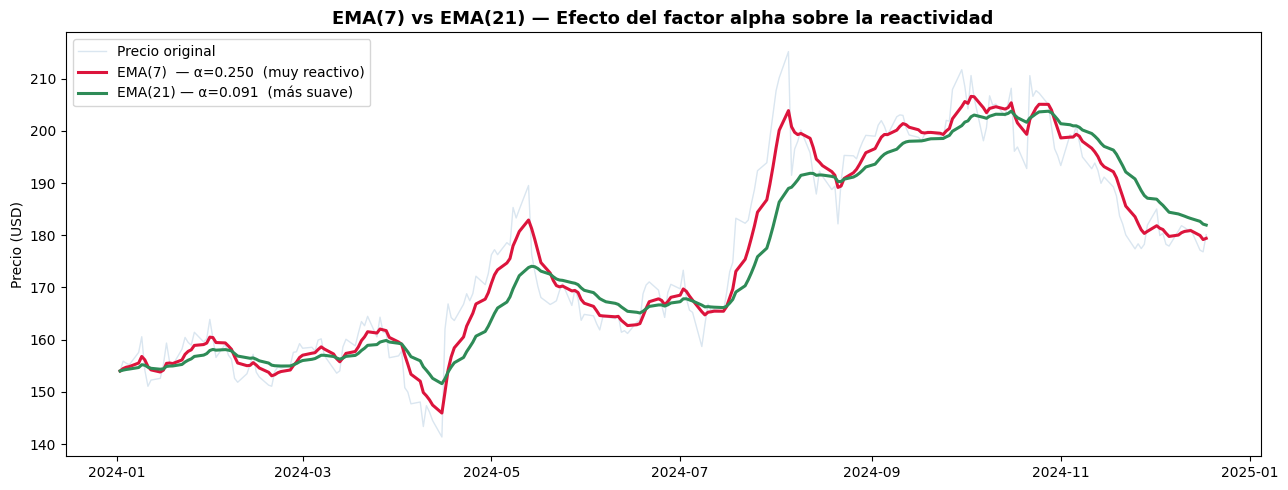

EMA(7)  α=0.250 → el precio de HOY pesa 25.0% — sigue de cerca el precio pero capta más ruido.
EMA(21) α=0.091 → el precio de HOY pesa  9.1% — más suave, mejor para ver la tendencia general.


In [8]:
# ── Gráfica: EMA(7) vs EMA(21) — efecto del factor alpha ─────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df["Precio"],  color="steelblue",  alpha=0.2, linewidth=1,   label="Precio original")
ax.plot(df.index, df["EMA_7"],   color="crimson",    linewidth=2.2, label=f"EMA(7)  — α=0.250  (muy reactivo)")
ax.plot(df.index, df["EMA_21"],  color="seagreen",   linewidth=2.2, label=f"EMA(21) — α=0.091  (más suave)")

ax.set_title("EMA(7) vs EMA(21) — Efecto del factor alpha sobre la reactividad", fontweight="bold")
ax.set_ylabel("Precio (USD)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("EMA(7)  α=0.250 → el precio de HOY pesa 25.0% — sigue de cerca el precio pero capta más ruido.")
print("EMA(21) α=0.091 → el precio de HOY pesa  9.1% — más suave, mejor para ver la tendencia general.")


## 📊 Paso 4 — EMA vs SMA

Con la misma ventana de **N=21 días**, comparamos SMA y EMA para ver cuál sigue mejor el precio real.

| Indicador | Peso al dato de hoy | Lag promedio |
|-----------|--------------------|--------------|
| SMA(21)   | 1/21 = **4.8%**    | $6.40 / día  |
| EMA(21)   | α = **9.1%**       | $5.11 / día  |

> El EMA está un **20.1% más cerca del precio real** que el SMA con la misma ventana.

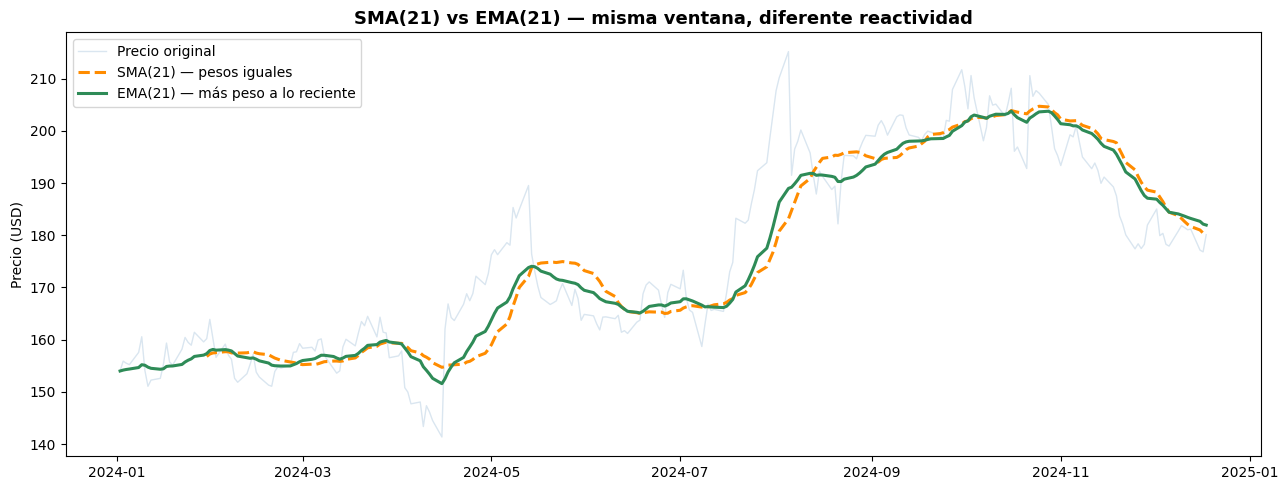

📊 Distancia promedio al precio real durante todo el año:
   SMA(21): $6.40 por día
   EMA(21): $5.11 por día
   ➡️  El EMA está 20.1% más cerca del precio real que el SMA.


In [9]:
# ── Graficamos EMA vs SMA vs Precio ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df['Precio'],  color='steelblue',  alpha=0.2, linewidth=1,   label='Precio original')
ax.plot(df.index, df['SMA_21'], color='darkorange',  linewidth=2.2, linestyle='--', label='SMA(21) — pesos iguales')
ax.plot(df.index, df['EMA_21'], color='seagreen',    linewidth=2.2, label='EMA(21) — más peso a lo reciente')

ax.set_title('SMA(21) vs EMA(21) — misma ventana, diferente reactividad', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Calculamos el lag (distancia al precio real) de cada uno
lag_sma = (df['SMA_21'] - df['Precio']).abs().mean()
lag_ema = (df['EMA_21'] - df['Precio']).abs().mean()

print(f"📊 Distancia promedio al precio real durante todo el año:")
print(f"   SMA(21): ${lag_sma:.2f} por día")
print(f"   EMA(21): ${lag_ema:.2f} por día")
print(f"   ➡️  El EMA está {((lag_sma-lag_ema)/lag_sma*100):.1f}% más cerca del precio real que el SMA.")


## 💹 Paso 5 — Señales de compra y venta: Golden Cross & Death Cross

Ahora usamos los promedios para tomar **decisiones automáticas**:

Comparamos **EMA(7)** (señal rápida) con **EMA(21)** (señal lenta):

| Situación | Nombre | ¿Qué significa? | Acción |
|-----------|--------|-----------------|--------|
| EMA(7) sube sobre EMA(21) | 🟡 Golden Cross | El precio está acelerando al alza | **COMPRAR** |
| EMA(7) baja bajo EMA(21)  | 🔴 Death Cross  | El precio está cayendo | **VENDER**  |

> 💡 Usamos EMA en vez de SMA para estas señales porque reacciona más rápido —  
> y en bolsa, unos pocos días de diferencia pueden importar mucho.


In [10]:
# ── Detectamos los cruces ────────────────────────────────────────────────────
# Señal: +1 cuando EMA corta > EMA larga  |  -1 cuando EMA corta < EMA larga
df['Signal'] = np.where(df['EMA_7'] > df['EMA_21'], 1, -1)

# Un cruce ocurre cuando la señal CAMBIA de signo
df['Cruce'] = df['Signal'].diff().fillna(0)

# Separamos las compras y ventas
compras = df[df['Cruce'] > 0]   # Golden Cross → COMPRAR
ventas  = df[df['Cruce'] < 0]   # Death Cross  → VENDER

print(f"🟡 Golden Cross — señales de COMPRA detectadas: {len(compras)}")
for fecha, row in compras.iterrows():
    print(f"   → {fecha.date()}   Precio: ${row['Precio']:.2f}")

print()
print(f"🔴 Death Cross — señales de VENTA detectadas: {len(ventas)}")
for fecha, row in ventas.iterrows():
    print(f"   → {fecha.date()}   Precio: ${row['Precio']:.2f}")


🟡 Golden Cross — señales de COMPRA detectadas: 9
   → 2024-01-03   Precio: $155.88
   → 2024-01-17   Precio: $159.35
   → 2024-02-28   Precio: $157.67
   → 2024-03-15   Precio: $160.07
   → 2024-04-17   Precio: $166.85
   → 2024-06-20   Precio: $170.47
   → 2024-07-17   Precio: $172.99
   → 2024-08-23   Precio: $195.29
   → 2024-10-23   Precio: $206.61

🔴 Death Cross — señales de VENTA detectadas: 9
   → 2024-01-12   Precio: $152.25
   → 2024-02-08   Precio: $152.59
   → 2024-03-12   Precio: $153.58
   → 2024-04-02   Precio: $157.83
   → 2024-05-21   Precio: $167.06
   → 2024-07-08   Precio: $158.68
   → 2024-08-21   Precio: $182.18
   → 2024-10-17   Precio: $196.08
   → 2024-10-30   Precio: $196.59


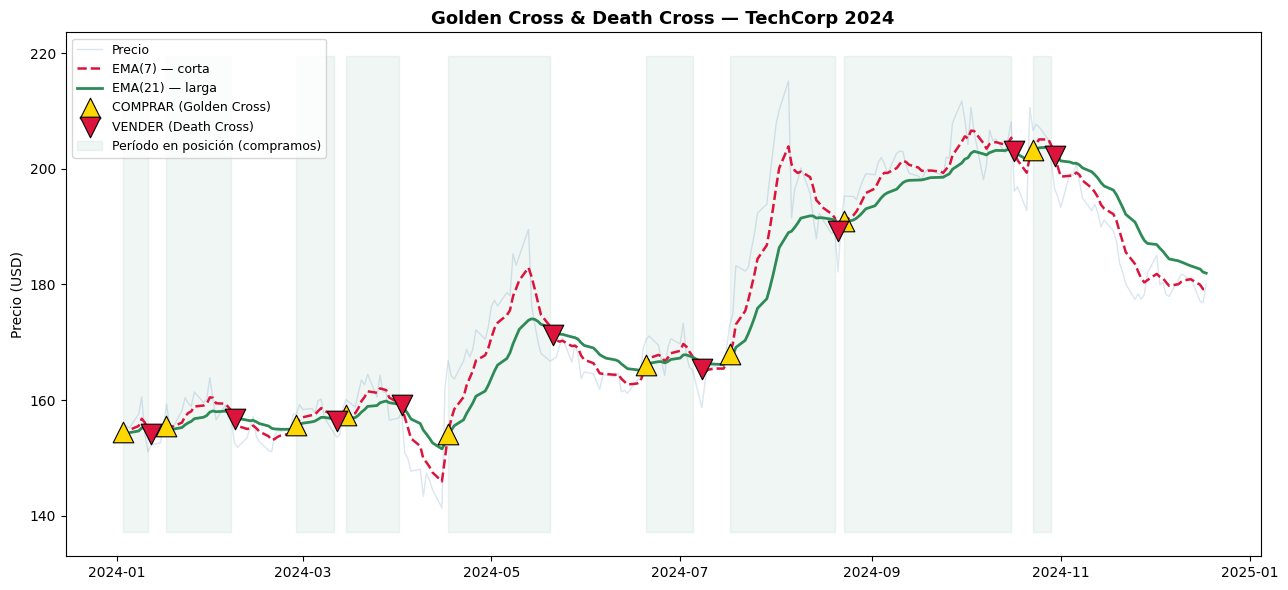

💡 Los triángulos dorados (▲) muestran cuándo compramos.
   Los triángulos rojos (▼) muestran cuándo vendimos.
   Las zonas verdes son los períodos en que estábamos 'en el mercado'.


In [11]:
# ── Graficamos las señales ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df.index, df['Precio'],  color='steelblue', alpha=0.2, linewidth=1,   label='Precio')
ax.plot(df.index, df['EMA_7'],   color='crimson',   linewidth=1.8, linestyle='--', label='EMA(7) — corta')
ax.plot(df.index, df['EMA_21'],  color='seagreen',  linewidth=2.0, label='EMA(21) — larga')

# Triángulos verdes = compra  |  Triángulos rojos = venta
ax.scatter(compras.index, compras['EMA_7'],
           marker='^', color='gold',   s=220, zorder=5,
           label='COMPRAR (Golden Cross)', edgecolors='black', linewidths=0.8)
ax.scatter(ventas.index,  ventas['EMA_7'],
           marker='v', color='crimson', s=220, zorder=5,
           label='VENDER (Death Cross)',  edgecolors='black', linewidths=0.8)

# Sombreamos los períodos donde estamos "en posición" (compramos y no hemos vendido)
ax.fill_between(df.index,
                df['Precio'].min() * 0.97, df['Precio'].max() * 1.02,
                where=(df['Signal'] == 1),
                alpha=0.07, color='seagreen', label='Período en posición (compramos)')

ax.set_title('Golden Cross & Death Cross — TechCorp 2024', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print("💡 Los triángulos dorados (▲) muestran cuándo compramos.")
print("   Los triángulos rojos (▼) muestran cuándo vendimos.")
print("   Las zonas verdes son los períodos en que estábamos 'en el mercado'.")
